# "Gaze-angle dependency of pupil-size measurements in head-mounted eye tracking"
## Comparing Pupil Labs and Tobii Pro Labs
This notebook contains Python code implementing all steps of the pupillometry analysis <br>
proposed by Petersch et al. and compares it to the gaze corrected pupil sizes of the Tobii pro glasses.<br>

The code cells are structured in the following sections<br>

A - Import of required packages, dependencies<br>
B - Definition of data loading routines and processing routines<br>
C - Definition of plotting routines<br>
D - Execution of entire data processing pipeline<br>

which, when executed sequentially from top to bottom will reproduce the main real world data result as shown in Fig.8 (panels A and C) of the manuscript.<br>
For ease of cross-reference, code cells in section C refer to the sections of the manuscript which detail the corresponding data processing steps.

## A - Imports & Dependencies

In [1]:
import pyarrow

In [1]:
# ---------------- Project path ----------------
from pathlib import Path
import sys

project_dir = Path.cwd().parents[1]
if str(project_dir) not in sys.path:
    sys.path.append(str(project_dir))


# ---------------- Standard imports ----------------
import cv2
import enum
import glob
import matplotlib.pyplot as plt
import msgpack
import numpy as np
import pandas as pd
import pickle
import pye3d.eye_model
import scipy.stats
import typing as T

# ---------------- Local imports ----------------
from setup import Setup, PATHS
from joblib import Parallel, delayed
from pupil_detectors import Detector2D
from pye3d.camera import CameraModel
from pye3d.geometry.primitives import Ellipse
from pye3d.observation import Observation
from pye3d.refraction import Refractionizer
from typing import List

## B - Data loading and Processing routines

### Data loading

In [2]:
class Trial(T.NamedTuple):
    video_path: str
    eye_id: int
    interval: tuple


def add_trials(run):
    """
    Collect trials (one per eye) from a recording run.
    """
    trials = []
    #interval = Setup.get_recording_interval()
    interval = (60,120)
    
    for dir_ in run.iterdir():
        if (dir_ / 'eye0_timestamps.npy').is_file():
            trials.append(
                Trial(
                    video_path=dir_,
                    eye_id=0,
                    interval = interval
                    
                )
            )

        if (dir_ / 'eye1_timestamps.npy').is_file():
            trials.append(
                Trial(
                    video_path=dir_,
                    eye_id=1,
                    interval = interval
                )
            )

    return trials


def get_all_trials(root_data_directory):
    """
    Collect all trials across runs.
    """
    all_trials = []

    for run in sorted([x for x in Path(root_data_directory).iterdir() if x.is_dir()]):
        all_trials += add_trials(run)

    return all_trials


def get_output_path(video_path,output_directory):
    relative_trial_path = Path(video_path.parent.name) / video_path.name
    output_path = output_directory / relative_trial_path
    output_path.mkdir(parents=True,exist_ok=True)

    return output_path,relative_trial_path

### Pupil contour extraction

In [3]:
def add_timestamps(pupil_detections, eye_id, video_path):
    
    """
    Adds timestamp information to pupil datums.
    Timestamp files contain exactly one timestamp per video frame and thus per pupil detection.

    Args:
        pupil_detections (list of dictionaries): previously calculated pupil datums
        eye_id (int): side of eye (0 or 1)
        video_path (pathlib Path): data directory of trial
    """
    
    timestamps = np.load(video_path / f"eye{eye_id}_timestamps.npy")
    timestamps -= timestamps[0]      # subtract first timestamp from all timestamps
     
    for ts, detection in zip(timestamps, pupil_detections):
        detection["timestamp"] = ts
        
    return pupil_detections

    
def shift_pupil_detections(pupil_detections, eye_id, video_path, resolution=(400,400)):
    
    """
    Load measured eye camera intrinsics from file and correct pupil datums
    for eye camera image sensor center shift.

    Args:
        pupil_detections (list of dictionaries): previously calculated pupil datums
        eye_id (int): side of eye (0 or 1)
        video_path (pathlib Path): data directory of trial
        resolution (int tuple): image resolution [pixels] (Default=(400,400))
    """
    
    # load camera matrix for correcting center shift     
    with (video_path / "camera_properties.p").open("rb") as f:
            camera_properties = msgpack.unpack(f, raw=False)
    
    if eye_id == 0:
        camera_matrix = np.array(camera_properties['right']['camera_matrix'])
    elif eye_id == 1:
        camera_matrix = np.array(camera_properties['left']['camera_matrix'])
    
    width, height = resolution
    center_shift = camera_matrix[:2, 2]
    dx = width / 2. - center_shift[0]
    dy = height / 2. - center_shift[1]
           
    for i in range(len(pupil_detections)):
        pupil_detections[i] = apply_shift(pupil_detections[i], dx, dy)

    return pupil_detections

    

def apply_shift(pd, dx, dy):
    
    x, y = pd["ellipse"]["center"]
    pd["ellipse"]["center"] = (x + dx, y + dy)
    
    return pd


    


def extract_pupil_contours(
    trial, output_directory, center_shift=True,
):
    
    """
    Loads eye video, segments pupil from every image and saves results.

    Args:
        trial (class Trial): object containing data directory of trial (video_path, pathlib Path),
        eye_id (side of eye, int 0 or 1) and start and end times of sweep period of experiment
        (class EnvironmentSweepPeriod, numeric values in seconds)
        center_shift (bool): whether to correct image sensor center shift (Default=True)
        output_directory (string): subdirectory to create for saving results
    """
        
    video_path = trial.video_path
    eye_id = trial.eye_id
    
    output_path,subject_path = get_output_path(video_path, output_directory)
    print(f"Working on: {subject_path} eye: {eye_id}")

    # INITIALIZE pupil detector
    detector = Detector2D()
    detector.update_properties(
        {
            "2d": {
                "intensity_range": 23,
                "pupil_size_max": 130,
                "pupil_size_min": 20
            }
        }
    )

    # LOAD eye video file
    file_ = video_path / f"eye{eye_id}.mp4"
    cap = cv2.VideoCapture(str(file_))
    ret, frame = cap.read()
    
    if not cap.isOpened():
        raise FileNotFoundError(f"Video not found: {file_}")
        
    # EXTRACT pupil contours
    pupil_detections = []

    while ret:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        pd_ = detector.detect(gray)
        pupil_detections.append(pd_)
        
        ret, frame = cap.read()

    # add TIMESTAMPS to pupil datums 
    pupil_detections = add_timestamps(pupil_detections, eye_id, video_path)
        
    # COMPENSATE camera sensor center shift
    if center_shift:        
        pupil_detections = shift_pupil_detections(pupil_detections, eye_id, video_path)
        
    # SAVE pupil detections to file
    if not (output_path).is_dir:
        (output_path).mkdir()
       
    with (output_path / f"eye{eye_id}_2d_detections.p").open("wb") as f:
        msgpack.pack(pupil_detections, f, use_bin_type=True)
    

### 3D eye model initialization

In [4]:
def filter_by_time(pupil_detections, start_time, end_time):

    """
    Return pupil detections within the requested timestamp interval.
    
    Args:
        pupil_detections (list of dictionaries): list of previously calculated pupil datums
        start_time (numeric): lower bound timestamp [s]
        end_time (numeric): upper bound timestamp [s]
    """

    return [
        _pd
        for _pd in pupil_detections
        if (start_time < _pd["timestamp"] < end_time)
    ]

def get_best_pupil_detections(pupil_detections, percentage=0.1):

    """
    Return the pupil detections with the highest confidence values.

    Args:
        pupil_detections (list of dictionaries): previously calculated pupil datums
        percentage (float): fraction of pupil datums of highest confidence to return
    """
    N = int(percentage * len(pupil_detections))
    
    confidences = np.asarray([_pd["confidence"] for _pd in pupil_detections])
    best_idx = np.argsort(confidences)[-N:]
    
    best_pupil_detections = [pupil_detections[i] for i in best_idx]
    return best_pupil_detections

def convert_pupil_datum_observation(pupil_datum, focal_length, resolution):

    """
    Converts pupil datum data as provided by pupil_detectors.Detector2D to Observation
    data object for processing by pye3d.eye_model.
    Ellipse angle is converted from the definition used in OpenCV to the one used in pye3d.

    Args:
        pupil_datum (dictionary): pupil datum
        resolution (int tuple): eye video image resolution [pixels] (Default=(400,400))
        focal_length (float): eye camera focal length [pixels] (Default=575.)
    """

    width, height = resolution
    
    # converting from image centered to camera centered [0-400],[0-400] -> [-200,200],[-200,200]
    center = (
        pupil_datum["ellipse"]["center"][0] - width / 2,
        pupil_datum["ellipse"]["center"][1] - height / 2,
    )
    
    minor_radius = pupil_datum["ellipse"]["axes"][0] / 2.0
    major_radius = pupil_datum["ellipse"]["axes"][1] / 2.0
    
    angle = (pupil_datum["ellipse"]["angle"] - 90.0) * np.pi / 180.0
    
    ellipse = Ellipse(center, minor_radius, major_radius, angle)

    return Observation(
        ellipse,
        pupil_datum["confidence"],
        pupil_datum["timestamp"],
        focal_length,
    )

def nandivision(n, d):
    return n / d if d else np.nan

def extract_predictions(
    trial,
    output_directory, 
    focal_length = 575.0, 
    resolution=(400,400), 
    save_file =True
):
    """
    Estimate gaze-angle and refraction- corrected pupil metrics-
    
    Loads pupil detections, calculates eyeball center positions based on given timestamp range,
    calculates pupil radii and refraction corrected pupil radii and saves results together with
    pupil ellipse major axis and circularity.

    Args:
        trial (class Trial): object containing data directory of trial (video_path), eye_id and
        start and end times of timestamp range from which to calculate eyeball center.
        output_directory (string): subdirectory used for saving results
    """

    video_path = trial.video_path
    eye_id = trial.eye_id
    start_time, end_time = trial.interval
    
    output_path,subject_path = get_output_path(video_path, output_directory)
    print(f"Working on: {subject_path} eye: {eye_id}")
    
    try:
        # load pupil contours
        with (output_path /  f"eye{eye_id}_2d_detections.p").open("rb") as f:
            pupil_detections = msgpack.unpack(f,raw=False)


        # calculate eyeball position based on pre-defined time interval ("sweep")
        # using only 10% pupil detections with highest confidence

        calibration_detections= filter_by_time(pupil_detections, start_time, end_time)
        best_pupil_detections = get_best_pupil_detections(calibration_detections, 0.1)

        camera = CameraModel(focal_length, resolution)
        eyemodel = pye3d.eye_model.TwoSphereModel(camera=camera)

        for pupil_datum in best_pupil_detections:
            observation = convert_pupil_datum_observation(
                pupil_datum,
                camera.focal_length,
                camera.resolution
            )
            eyemodel.add_observation(observation)

        sphere_center = eyemodel.estimate_sphere_center().three_dim

        
        # CALCULATE pupil radii and gaze vectors

        circles_3d = np.asarray(
            [
                eyemodel.predict_pupil_circle(
                    convert_pupil_datum_observation(
                        pupil_datum,
                        focal_length,
                        resolution
                    )
                )
                for pupil_datum in pupil_detections
            ]
        )
        gaze_vectors = np.asarray([circle.normal for circle in circles_3d])
        radii = np.asarray([circle.radius for circle in circles_3d])
        radii.shape = -1, 1

        # Calculate refraction corrected pupil radii
        n_detections = len(circles_3d)
        sphere_centers = np.repeat([sphere_center], repeats=n_detections, axis=0)
        refraction_input = np.hstack((sphere_centers, gaze_vectors, radii))

        refractionizer = Refractionizer()
        radii_refraction = refractionizer.correct_radius(refraction_input)[:, 0]

        
        # SAVE data
        predictions = pd.DataFrame(
            [
                {
                    "major": entry["ellipse"]["axes"][1],
                    "circularity": nandivision(
                        entry["ellipse"]["axes"][0],
                        entry["ellipse"]["axes"][1]
                    ),
                    "confidence": entry["confidence"],
                    "timestamp": entry["timestamp"],
                }
                for entry in pupil_detections
            ]
        )
        predictions["radius_refraction"] = radii_refraction

        # add tobii here:
        predictions["radius_tobii"] = radii

        predictions.to_parquet(
            (
                 output_path / f"eye{eye_id}_2d_predictions.p"
            )
        )

        # delete later, using radii as substitue for tobii
        return radii

    except Exception as e:
        print("Exception:", e)
        print("... was thrown in trial:", str(video_path), "!")


### Pupil size baselines calculation

In [5]:
def calculate_pupil_size_baselines(trail,output_directory, conf_thresh=0.6 , SAVE=True):

    """
    Loads predicted pupil sizes, takes measurements with a certain confidence,
    circularity, and time window and calculates the median 
    
    Calculates the baseline of radius, refracted_radius and major as the median
    value during sweep period.
    
    Args:
        all_trials: list of data directories and metadata of individual
        recordings as produced using get_all_trials(root_data_directory)
        conf_thresh (float): confidence threshold for BASELINE pupil size calculation (Default=0.6)
        output_directory (string): subdirectory to load pupil size data from
    """
    try:
        video_path = trial.video_path
        eye_id = trial.eye_id
        start_time, end_time = trial.interval

        output_path,subject_path = get_output_path(video_path, output_directory)
        print(f"Working on: {subject_path} eye: {eye_id}")
            
        # extract subject_ID
        name = video_path.parent.name

        # extract time range for baseline calculation
        duration = end_time - start_time
        

        # LOAD pupil size data

        dataframe = pd.read_parquet(output_path/ f"eye{eye_id}_2d_predictions.p")
        condition = (dataframe.confidence > conf_thresh) & (~pd.isna(dataframe.circularity))
        
        # CALCULATE pupil size baselines from sweep period and add to dataframe
        sweep_period = (dataframe.timestamp.between(start_time, end_time)) & condition

        metrics = ["major", "radius_refraction", "radius_tobii"]
        for met in metrics:
            dataframe[f"baseline_{met}"] = dataframe.loc[sweep_period, met].median(skipna=True)

        dataframe['eye'] = "left" if eye_id == 1 else "right"
        dataframe['name'] = name
        #dataframe['t_end_baseline'] = start_time
            
        dataframe = dataframe[(~pd.isna(dataframe.circularity))]
        return dataframe

    except Exception as e:
        print("Exception:", e)
        print("... was thrown in trial:", str(video_path), "!")


### Routines for calculation of circularity binned relative, average, normalized pupil radii statistics

In [19]:
def get_binned_statistics(df, column, bins):
    
    """
    Calculates confidence-weighted mean of values contained in "column" of
    pandas dataframe df divided by their corresponding "baseline_column" value,
    within bins of equal circularity.
    
    calculate confidence-weighted mean of relative radius (column / baseline_column)
    in circularity bins, normalized to the highes valid circularity bin, . 

    Args:
        df (pandas dataframe): input dataframe
        column (string): heading of column of values to calculate statistics on
        confidence_sum (numeric): sum of confidence values of those data values
        nof_samples (numeric): count of data values
        bins (list, numeric): bin edge values
    """

    relative_value = df[column] / df[f"baseline_{column}"]

    weighted_sum = scipy.stats.binned_statistic(
        df["circularity"],
        df["confidence"] * relative_value,
        statistic = "sum",
        bins = bins,
    ).statistic

    confidence_sum = scipy.stats.binned_statistic(
        df["circularity"],
        df["confidence"],
        statistic = "sum",
        bins = bins,
    ).statistic

    weighted_mean = np.divide(
        weighted_sum, 
        confidence_sum,
        out=np.full_like(weighted_sum, np.nan, dtype=float),
        where=confidence_sum > 0,
    )
    valid = np.isfinite(weighted_mean)

    if not valid.any():
        return np.full_like(weighted_mean, np.nan, dtype=float)

    reference = weighted_mean[valid][-1]

    return weighted_mean / reference



def calculate_pupil_size_statistics(
    dataframe_all,
    output_path,
    n_of_bins = 10,
    t_start = 60,
    t_end = 120,
    conf_thresh  = 0.0,
    max_maj_axis_deviation = 0.2,
    SAVE = True,
):
    """
    Calculates pupil size statistics (mean) for pupil radius, refraction corrected pupil radius and major
    axis, relative to their respecitve baselines in bins of equal circularity, normalized to value of 
    highest circularity bin. 
    
    Args:
        dataframe_all (pandas dataframe): input dataframe
        nof_bins (int): number of circularity bins (Default=10)
        t_sweep_duration (numeric): duration of period to include into analysis [s] (Default=60.0)
        conf_thresh (float): minimum pupil detection confidence of data points to include into analysis
                             (Default=0.0)
        max_maj_axis_deviation (float): data samples with major axis or radius deviation from baseline larger
        than this fraction are considered spurious pupil detections and excluded from analysis (Default=0.2)
        see manuscript STEP 2.i)
    """

    # bins
    binny = np.linspace(0.,1.,n_of_bins+1)

    radius_tobii = []
    radius_3dmodel_corrected = []
    major_axis = []

    subjects = np.unique(dataframe_all.name)

    for name in subjects:

        # separate results for left and right eye
        for side in ["left","right"]:
            # Conditions include: subject, confidence, non NaN, time frame, 
            condition = (
                dataframe_all["name"].eq(name)
                & dataframe_all["confidence"].gt(conf_thresh)
                & dataframe_all["circularity"].notna()
                & dataframe_all["timestamp"].between(t_start,t_end,inclusive="neither")
                & dataframe_all["eye"].eq(side)
                & ((dataframe_all["major"] / dataframe_all["baseline_major"] - 1).abs() < max_maj_axis_deviation)
            )

            # scaling factors used for WEIGHTING by confidence
            radius_tobii.append(
                get_binned_statistics(
                    dataframe_all[condition],
                    "radius_tobii",
                    binny
                )
            )

            radius_3dmodel_corrected.append(
                get_binned_statistics(
                    dataframe_all[condition],
                    "radius_refraction",
                    binny
                )
            )

            major_axis.append(
                get_binned_statistics(
                    dataframe_all[condition],
                    "major",
                    binny
                )
            )
                
    if SAVE:
        save_dir = Path(str(output_path))
        save_dir.mkdir(parents=True, exist_ok=True)
        np.save(save_dir /"radius_tobii.npy", np.array(radius_tobii), allow_pickle=True)
        np.save(save_dir / "radius_3dmodel_corrected.npy", np.array(radius_3dmodel_corrected), allow_pickle=True)
        np.save(save_dir / "major_axis.npy", np.array(major_axis), allow_pickle=True)
            
    return radius_tobii, radius_3dmodel_corrected, major_axis


def calculate_population_statistics(radius_tobii, radius_3dmodel_corrected, major_axis):
    
    radius_tobii_mean = np.nanmean(np.array(radius_tobii), axis=0)
    radius_3dmodel_corrected_mean = np.nanmean(np.array(radius_3dmodel_corrected), axis=0)
    major_axis_mean = np.nanmean(np.array(major_axis), axis=0)
    
    std_tobii = np.nanstd(np.array(radius_tobii), axis=0)
    std_3dmodel_corrected = np.nanstd(np.array(radius_3dmodel_corrected), axis=0)
    std_major_axis = np.nanstd(np.array(major_axis), axis=0)
    
    return radius_tobii_mean, radius_3dmodel_corrected_mean, major_axis_mean, std_tobii, std_3dmodel_corrected, std_major_axis

### Plotting routine for results per subject eye & population average

In [20]:
def plot_results(radius_3dmodel, radius_3dmodel_corrected, major_axis, radius_3dmodel_mean, radius_3dmodel_corrected_mean, major_axis_mean, std_3dmodel, std_3dmodel_corrected, std_major_axis):
   
    plt.rcParams['xtick.major.pad']='20'
    fig, ax = plt.subplots(figsize=(14, 11))

    # offset for plotting values at the center of the each bin
    binny = np.linspace(0.,1.,len(radius_3dmodel[0])+1)
    delta = (binny[1]-binny[0])/2.

    alpha = 0.5

    for i in range(len(radius_3dmodel)):
        ax.plot(binny[:-1]+delta, radius_3dmodel[i], c='blue', alpha=alpha, linewidth=2.)
        ax.plot(binny[:-1]+delta, radius_3dmodel_corrected[i], c='green', alpha=alpha, linewidth=2.)
        ax.plot(binny[:-1]+delta, major_axis[i], c='red', alpha=alpha, linewidth=2.)

    ax.set_title("\nReal world data\n", fontsize=30)
    ax.set_ylabel("Relative pupil size [%]\n", fontsize=30)
    ylim = (0.9, 1.1)
    xlim = (0.4, 1.0)
    ytik = [0.9, 0.925, 0.95, 0.975, 1.0, 1.025, 1.05, 1.075, 1.1]
    ylab = ["90.0", "92.5", "95.0", "97.5", "100.0", "102.5", "105.0", "107.5", "110.0"]
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)
    ax.yaxis.grid(True)
    ax.vlines(x=binny, ymin=ylim[0], ymax=ylim[1], linestyles='-', colors='gray')
    ax.axhline(0.99, linestyle='--', color='black', alpha=0.8, linewidth=2.)
    ax.axhline(1.01, linestyle='--', color='black', alpha=0.8, linewidth=2.)
    ax.set_yticks(ytik)
    ax.set_yticklabels(ylab, fontsize=26)
    ax.tick_params(axis='x', labelsize=26)
    textstr = 'A'
    props = dict(fill=False, facecolor=None, alpha=0.)
    ax.text(0.9, 0.08, textstr, transform=ax.transAxes, fontsize=36,
            verticalalignment='top', bbox=props, weight="bold")

    fig.tight_layout()

    fig2, ax2 = plt.subplots(figsize=(14, 11))

    ax2.plot(binny[:-1]+delta, radius_3dmodel_mean, "o--", c='blue', label="3D-1p")
    ax2.plot(binny[:-1]+delta, radius_3dmodel_corrected_mean, "o--", c='green', label="3D-4p")
    ax2.plot(binny[:-1]+delta, major_axis_mean, "o--", c='red', label="Major axis")

    alpha = 0.2

    ax2.fill_between(binny[:-1]+delta,
                    radius_3dmodel_mean-std_3dmodel,
                    radius_3dmodel_mean+std_3dmodel,
                    alpha=alpha,
                    facecolor='blue')
    ax2.fill_between(binny[:-1]+delta,
                    radius_3dmodel_corrected_mean-std_3dmodel_corrected,
                    radius_3dmodel_corrected_mean+std_3dmodel_corrected,
                    alpha=alpha,
                    facecolor='green')
    ax2.fill_between(binny[:-1]+delta,
                    major_axis_mean-std_major_axis,
                    major_axis_mean+std_major_axis,
                    alpha=alpha,
                    facecolor='red',
                   )

    ax2.set_ylabel("Relative pupil size [%]\n", fontsize=30)
    ax2.set_xlabel("\nCircularity", fontsize=30)
    ylim = (0.9, 1.1)
    xlim = (0.4, 1.0)
    ytik = [0.9, 0.925, 0.95, 0.975, 1.0, 1.025, 1.05, 1.075, 1.1]
    ylab = ["90.0", "92.5", "95.0", "97.5", "100.0", "102.5", "105.0", "107.5", "110.0"]
    ax2.set_ylim(ylim)
    ax2.set_xlim(xlim)
    ax2.yaxis.grid(True)
    ax2.vlines(x=binny, ymin=ylim[0], ymax=ylim[1], linestyles='-', colors='gray')
    ax2.axhline(0.99, linestyle='--', color='black', alpha=0.8, linewidth=2.)
    ax2.axhline(1.01, linestyle='--', color='black', alpha=0.8, linewidth=2.)
    ax2.set_yticks(ytik)
    ax2.set_yticklabels(ylab, fontsize=26)
    ax2.tick_params(axis='x', labelsize=26)
    textstr = 'C'
    props = dict(fill=False, facecolor=None, alpha=0.)
    ax2.text(0.9, 0.08, textstr, transform=ax2.transAxes, fontsize=36,
             verticalalignment='top', bbox=props, weight="bold")
    ax2.legend(loc='upper right', facecolor='white', frameon = 1, framealpha=1, fontsize=30)
    fig2.tight_layout()
    
    return fig, fig2

## D - Execute data processing pipeline

### Get recording data folders

Set data root path and number of CPUs to use (single-thread or multi-core parallel processing)

In [8]:
root_path = PATHS["exp1_output_dir"]
intermediate_path = PATHS["exp1_intermediate_dir"]
processed_path = PATHS["exp1_processed_dir"]
SAVE = True

In [9]:
all_trials = get_all_trials(root_path)
print(f"Number of individual recordings: {len(all_trials)}")

Number of individual recordings: 2


In [10]:
n_jobs = 1
#n_jobs = 8

### Extract pupil contours

In [11]:
if n_jobs == 1:
    for trial in all_trials:
        extract_pupil_contours(trial, intermediate_path)
else:
    result = Parallel(n_jobs=n_jobs)(delayed(extract_pupil_contours)(trial,intermediate_path) for trial in all_trials[:2])

Working on: subject_01\trial_01 eye: 0
Working on: subject_01\trial_01 eye: 1


### Calculate pupil sizes

In [12]:
if n_jobs == 1:
    for trial in all_trials:
        extract_predictions(trial, intermediate_path)
else:
    result = Parallel(n_jobs=n_jobs)(delayed(extract_predictions)(trial,intermediate_path) for trial in all_trials[:2])

Working on: subject_01\trial_01 eye: 0
Working on: subject_01\trial_01 eye: 1


### Add Tobii Eyetracking data

### Calculate pupil size baselines

In [13]:
frames = []

for trial in all_trials:
    dataframe = calculate_pupil_size_baselines(all_trials, intermediate_path)
    frames.append(dataframe)
dataframe_all = pd.concat(frames)

if SAVE:
    dataframe_all.to_parquet("dataframe_all_code_example.p")
    


Working on: subject_01\trial_01 eye: 0
Working on: subject_01\trial_01 eye: 1


### Routines for calculation of circularity binned relative, average, normalized, pupil radii statistics

In [22]:
%%capture   #hide RunTimeWarning
radius_tobii, radius_3dmodel_corrected, major_axis = calculate_pupil_size_statistics(dataframe_all, processed_path)

radius_tobii_mean, radius_3dmodel_corrected_mean, major_axis_mean, std_tobii, std_3dmodel_corrected, std_major_axis = calculate_population_statistics(radius_tobii,radius_3dmodel_corrected, major_axis)

## Plot results

### compare manuscript Fig.8 panels A, C

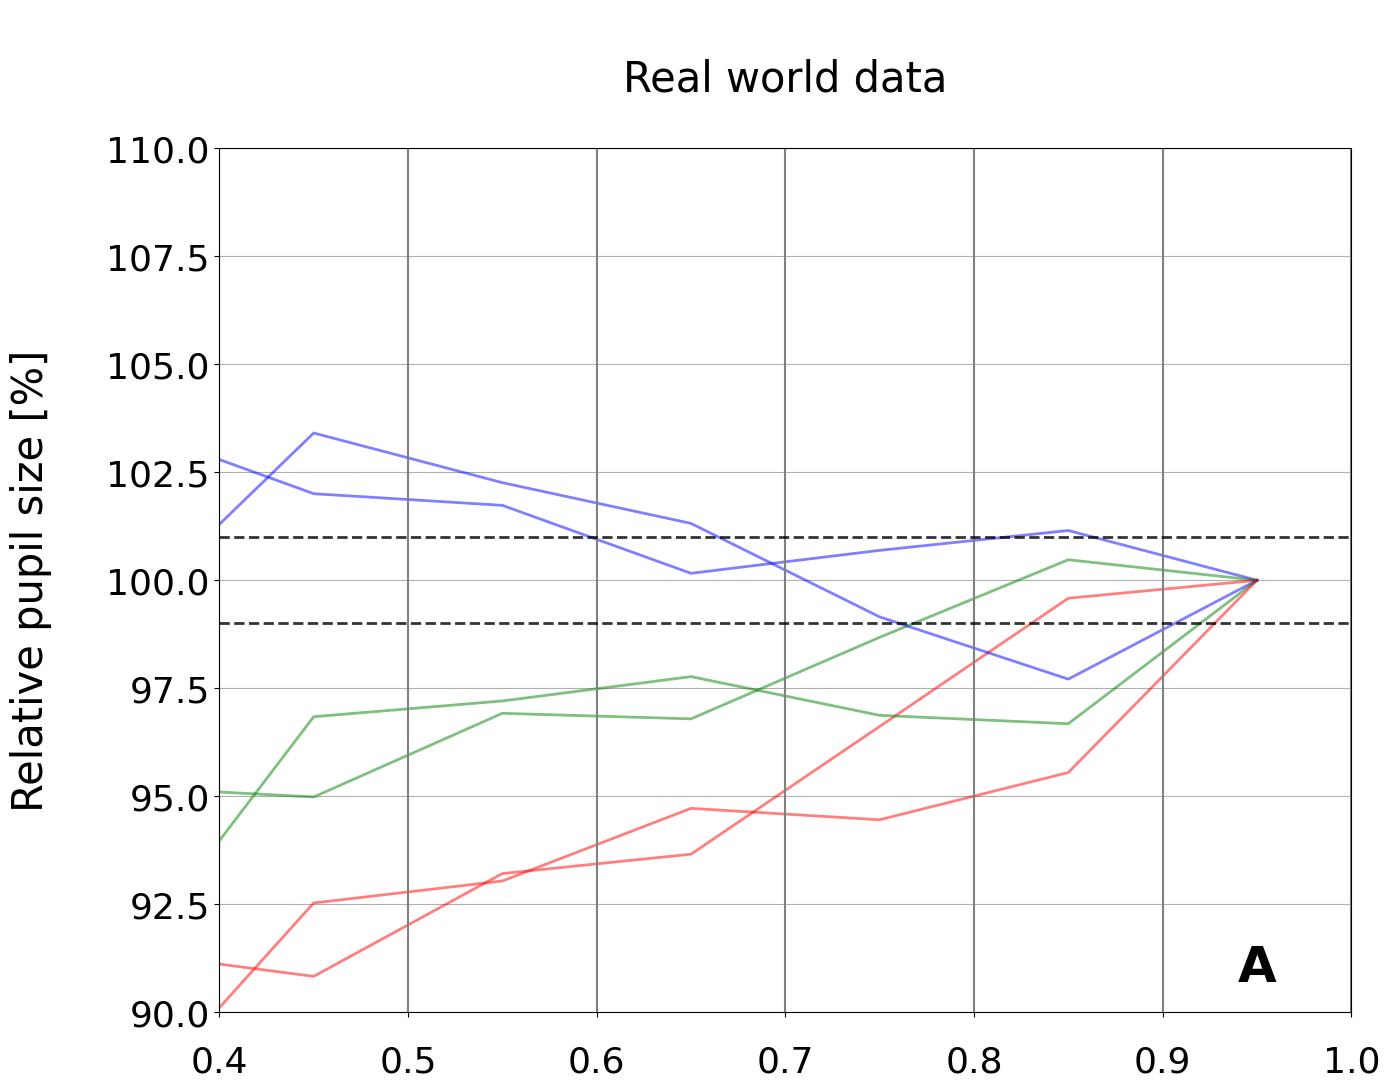

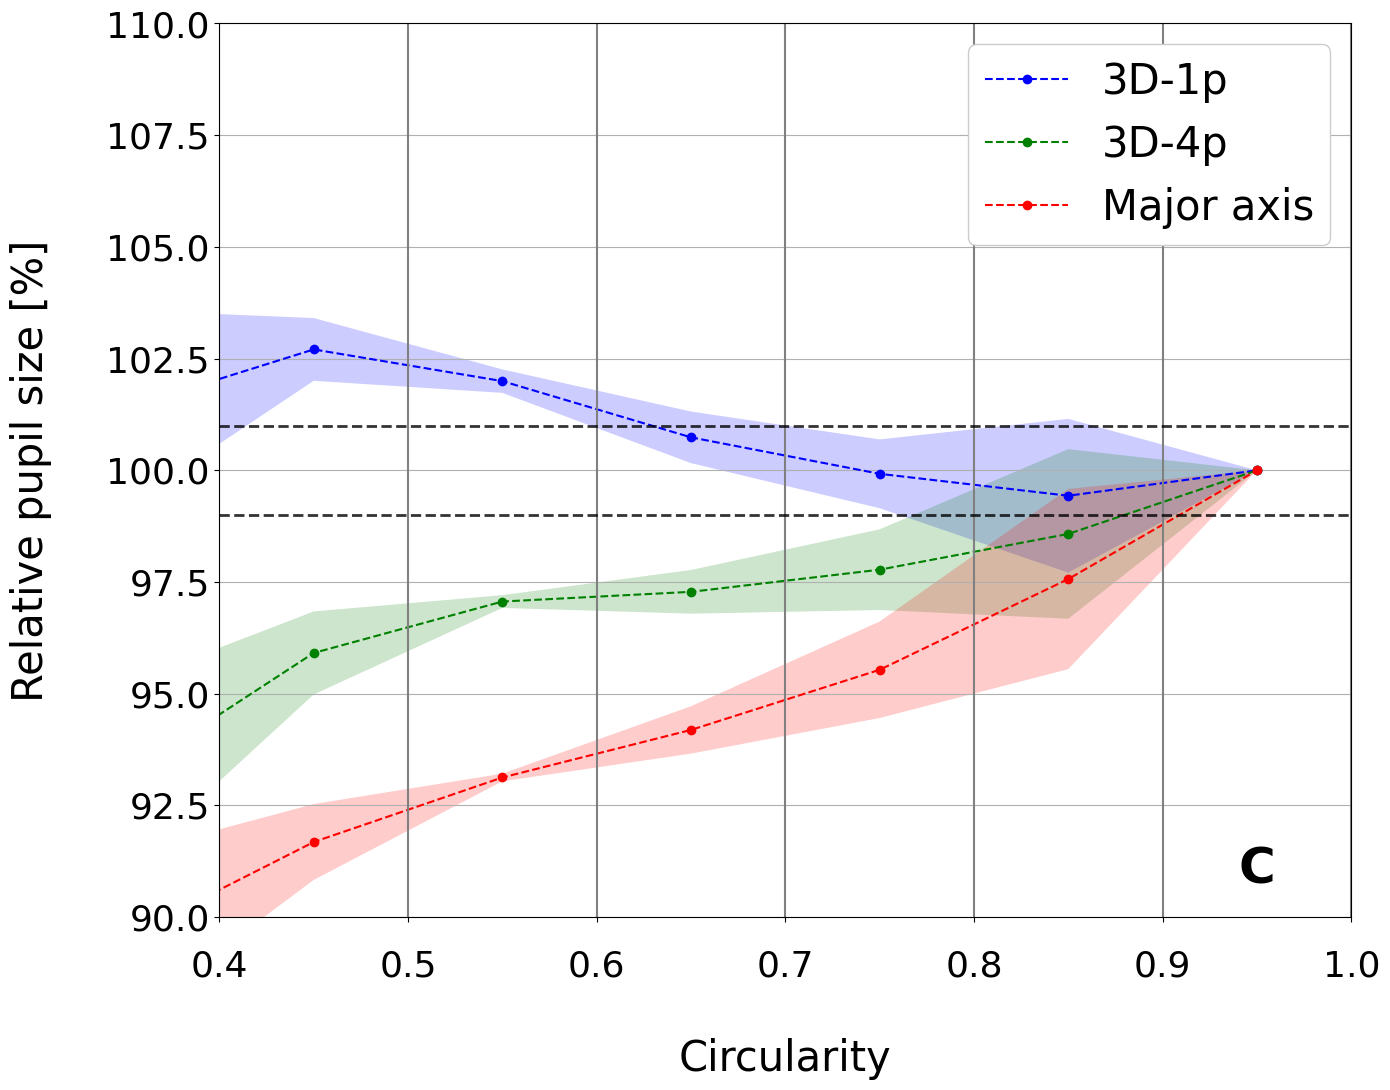

In [32]:
fig8A, fig8C = plot_results(
    radius_tobii,
    radius_3dmodel_corrected,
    major_axis,
    radius_tobii_mean,
    radius_3dmodel_corrected_mean,
    major_axis_mean,
    std_tobii,
    std_3dmodel_corrected,
    std_major_axis
)

## Hayes and Petrov

## Comparing Petersch, Hayes and Tobii

### Ideas

Remove data with detection confidence < 97%  
Add velocity filter <br>
Rebuild missing data using interpolation ~ Zandi

when using a built model for the pupil prediction of experiment 2. compare all models built for the subject, also include the mean model. see what fits best compared to Tobii. 
or which one generates the best results...

We ultimately seek to shed light on the variation of
pupil size as a function of gaze angle. Both model-based
methods, for each eye image also provide a gaze-angle
estimate. The respective estimates, however, depend both on model assumptions as well as the choice of model-specific
parameters. Striving for a more objective measure, we
decided to use circularity C of the 2D pupil ellipse instead.


find a paper, that verifies tobii, gaze angle accuracy, use gaze angle as variable. 

## To do before analysing
- remove [:2] from for loop looping through all 
- CameraModel(focal_length=575.,resolution(400,400))
   - resolution (int tuple): eye video image resolution [pixels] (Default=(400,400))
   - focal_length (float): eye camera focal length [pixels] (Default=575.)<br>
   - 
- Extract Camera properties for each trial save it under camera_properties

In [46]:
print(Path.cwd())
print(processed_path)

C:\Users\stock\Documents\Master BME\Masterarbeit\PupilResponseModel\analysis\exp1_gaze_angle
C:\Users\stock\Documents\Master BME\Masterarbeit\PupilResponseModel\data\processed\exp1


#### If Petersch is best

In [110]:



def build_eyemodel(trial,output_directory="analysis"):
    """ 
    Loads pupil detection, calculates eyeball center position based on given timestamp range
    and saves results for further refraction corrected pupil radii calculations
    
    Args:
        trial (class Trial): object containing data directory of trial (video_path, pathlib Path),
        eye_id (side of eye, int 0 or 1) and start and end times of timestamp range from which to
        calculate eyeball center (class EnvironmentSweepPeriod, numeric values in seconds)
        output_directory (string): subdirectory to use for saving results
    """
    video_path = trial.video_path
    eye_id = trial.eye_id
    start_time,end_time = trial.interval
    print(str(video_path), eye_id, start_time, end_time)
    
    analysis_path = video_path / output_directory
    analysis_path.mkdir(exist_ok = True)
    
    with (analysis_path / f"eye{eye_id}_2d_detections.p").open("rb") as f:
        pupil_detections = msgpack.unpack(f, raw=False)

    # CALCULATE eyeball position based on pre-defined time interval ("sweep")
    # using only 10% pupil detections with highest confidence

    pupil_detections_sweep = filter_by_time(pupil_detections, start_time, end_time)
    best_pupil_detections = get_best_pupil_detections(pupil_detections_sweep, 0.1)

    camera = CameraModel(focal_length=575., resolution=(400, 400))
    eyemodel = pye3d.eye_model.TwoSphereModel(camera=camera)

    for pupil_datum in best_pupil_detections:
        observation = convert_pupil_datum_observation(pupil_datum,camera.resolution, camera.focal_length)
        eyemodel.add_observation(observation)

    sphere_center = eyemodel.estimate_sphere_center().three_dim
    
    data = {
        "eyemodel": eyemodel,
        "sphere_center": sphere_center
    }
    
    with (analysis_path / f"eye{eye_id}_eyemodel.pkl").open("wb") as f:
        pickle.dump(data, f)

    
def extract_and_save_predictions(trial,eyemodel_data=None, output_directory="analysis"):
    video_path= trial.video_path
    eye_id = trial.eye_id
    
    if eyemodel_data is None:
        with(video_path / output_directory / f"eye{eye_id}_eyemodel.pkl").open("rb") as file:
            eyemodel_data = pickle.load(file)
            
    eyemodel = eyemodel_data["eyemodel"]
    sphere_center = eyemodel_data["sphere_center"]
    
    
    with(video_path / output_directory / f"eye{eye_id}_2d_detections.p").open("rb") as file:
        pupil_detections = msgpack.unpack(file,raw=False)
        
    refractionizer = Refractionizer()
    
    # CALCULATE pupil radii and gaze vectors

    circles_3d = np.asarray([
            eyemodel.predict_pupil_circle(
                convert_pupil_datum_observation(pupil_datum)
            )
            for pupil_datum in pupil_detections
    ])
    
    gaze_vectors = np.asarray([circle.normal for circle in circles_3d])
    radii = np.asarray([circle.radius for circle in circles_3d])
    radii.shape = -1, 1

    
    # CALCULATE refraction corrected pupil radii

    N = len(circles_3d)
    sphere_center_column = np.repeat([sphere_center], repeats=N, axis=0)
    
    X = np.hstack((sphere_center_column, gaze_vectors, radii))
    radii_refraction = refractionizer.correct_radius(X)[:, 0]

    # SAVE data

    df = pd.DataFrame(
        [
            {
                "circularity": nandivision(
                    entry["ellipse"]["axes"][0], entry["ellipse"]["axes"][1]
                ),
                "confidence": entry["confidence"],
                "timestamp": entry["timestamp"],
            }
            for entry in pupil_detections
        ]
    )
    df["radius_refraction"] = radii_refraction
    df.to_parquet(
        (
            video_path / output_directory / f"eye{eye_id}_2d_predictions.p"
        )
    )
    

In [ ]:
if n_jobs == 1:
    for trial in all_trials[:2]:
        #extract_predictions(trial, intermediate_path)
        build_eyemodel(trial)
        extract_and_save_predictions(trial)
else:
    result = Parallel(n_jobs=n_jobs)(delayed(extract_predictions)(trial) for trial in all_trials[:2])

## Ignore

In [41]:
import importlib
import setup as setup_module

importlib.reload(setup_module)

PATHS = setup_module.PATHS
Setup = setup_module.Setup


start_time, end_time = Setup.get_recording_interval()
print(start_time, end_time)

1.0 13.0


In [ ]:
for trial in all_trials:
    with (trial.video_path / "camera_properties.p").open("rb") as f:
        print( msgpack.unpack(f, raw=False))
    
    #print(output_path / str(trial.video_path)[-19::1])

In [117]:
folder =trial.video_path
print(folder)

C:\Users\stock\Documents\Master BME\Masterarbeit\PupilResponseModel\data\raw\exp1\subject_01\trial_01


In [119]:
    # extract test subject ID
            # parts[-2] = 'subject_05-B1'
n = folder.parent.name
name = folder.parts[-2].split('-')[0]
name

'subject_01'

In [120]:
n

'subject_01'

In [30]:
for trial in all_trials:
    start_time, end_time = trial.interval

    print(start_time, end_time)

1.0 13.0
1.0 13.0


In [15]:
n_of_bins = 10
t_start = 60
t_end = 120
conf_thresh  = 0.0
max_maj_axis_deviation = 0.2
# bins
binny = np.linspace(0.,1.,n_of_bins+1)

tobii = []
radius_3dmodel_corrected = []
major_axis = []

subjects = np.unique(dataframe_all.name)

for name in subjects:
    # separate results for left and right eye
    for side in ["left","right"]:
        # Conditions include: subject, confidence, non NaN, time frame, 
        condition = (
            dataframe_all["name"].eq(name)
            & dataframe_all["confidence"].gt(conf_thresh)
            & dataframe_all["circularity"].notna()
            & dataframe_all["timestamp"].between(t_start,t_end,inclusive="neither")
            & dataframe_all["eye"].eq(side)
            & ((dataframe_all["major"] / dataframe_all["baseline_major"] - 1).abs() < max_maj_axis_deviation)
        )

        # scaling factors used for WEIGHTING by confidence
        print(name,side)
        confidence_sum = scipy.stats.binned_statistic(
            dataframe_all[condition].circularity,
            dataframe_all[condition].confidence,
            statistic='sum',
            bins=binny
        ).statistic
        n_of_samples = scipy.stats.binned_statistic(
            dataframe_all[condition].circularity,
            dataframe_all[condition].radius_refraction,
            statistic='count',
            bins=binny
        ).statistic
        print(confidence_sum)
        print( n_of_samples)
        

subject_01 left
[  0.           0.           0.          15.89525565 115.38759541
 138.81421365 169.08166485 231.07957109 254.86795026 128.6239344 ]
[  0.   0.   0.  21. 134. 144. 181. 251. 284. 149.]
subject_01 right
[  0.           0.           0.           4.14230315  74.84336122
 121.76035292 145.42590324 156.11279059 254.20604273 216.36921207]
[  0.   0.   0.   7.  93. 144. 167. 166. 271. 237.]
